In [1]:
import os
import numpy as np
import copy

import matplotlib as mpl
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt

import numpy as np
from scipy.integrate import quad
from scipy.interpolate import make_interp_spline
from numpy.polynomial import polynomial

In [2]:
from icecube.icetray import OMKey
from icecube import dataio, dataclasses, simclasses

In [4]:
%env PONESRCDIR '/home/users/fhenningsen/pone_offline'
from WaterOpticalModel import MakePoneMediumPropertiesConservativeExtendedRange as Medium
from Utilities import DOMUtility

env: PONESRCDIR='/home/users/fhenningsen/pone_offline'


## Check GCD

In [5]:
#Using new GCD:
geometry = dataio.I3File('/home/users/fhenningsen/pone_offline/GCD/PONE_Phase1.i3.gz')

gframe = geometry.pop_frame()  
geo = gframe["I3Geometry"] #access geo file via key
all_dom_keys = geo.omgeo.keys()

print(all_dom_keys[:5])
print('...')
print(all_dom_keys[-5:])

[OMKey(1,1,1), OMKey(1,1,2), OMKey(1,1,3), OMKey(1,1,4), OMKey(1,1,5)]
...
[OMKey(10,20,12), OMKey(10,20,13), OMKey(10,20,14), OMKey(10,20,15), OMKey(10,20,16)]


In [6]:
for i in all_dom_keys[::1970]:
    print(i, geo.omgeo[i])

OMKey(1,1,1) [I3OMGeo Position: I3Position(12.5,-21.6506,-450)
      Orientation: I3Orientation: 
    Dir: (0,0,-1)
     Up: (1,0,0)
  Right: (0,-1,0)
           OMType: 130
             Area: 0.585754 ]
OMKey(7,4,3) [I3OMGeo Position: I3Position(-12.5,21.6506,-300)
      Orientation: I3Orientation: 
    Dir: (0,0,-1)
     Up: (1,0,0)
  Right: (0,-1,0)
           OMType: 130
             Area: 0.585754 ]


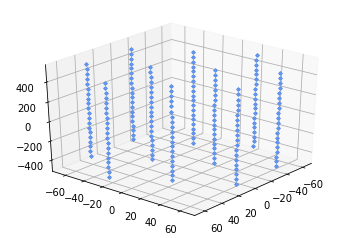

In [7]:
fig = plt.figure()
ax = plt.axes(projection='3d')

for i in all_dom_keys:
    om = geo.omgeo[i]
    x, y, z = om.position[0], om.position[1], om.position[2]
    ax.scatter(x, y, z, color='cornflowerblue', s=5)
    ax.view_init(30, 40)

## Check optical properties

In [8]:
m = Medium.MakePoneMediumProperties()

In [11]:
# from WaterOpticalModule/MakePoneMediumPropertiesConservativeExtendedRange.py
# https://github.com/pone-software/pone_offline/blob/608423314880fe96e9bebf191923a9dd111aefa6/WaterOpticalModel/MakePoneMediumPropertiesConservativeExtendedRange.py
absLenTable = [ 0.800,   1.629,   2.457,   3.286,   4.114,   4.943,   5.771,   6.600,   7.429,
                8.257,   9.086,  10.214,  11.643,  13.071,  14.500,  17.520,  20.540,  23.560,
               26.580,  29.600,  27.911,  26.222,  24.533,  22.844,  21.156,  19.467,  17.778,
               16.089,  14.400,  12.711,  11.022,   9.333,   7.644,   6.563,   6.089,   5.615,
                5.141,   4.667,   4.193,   3.720,   3.246,   2.772,   2.298,   1.824,   1.350,
                0.876]
wls = np.linspace(m.GetMinWavelength(), m.GetMaxWavelength(), len(absLenTable)) * 1e9

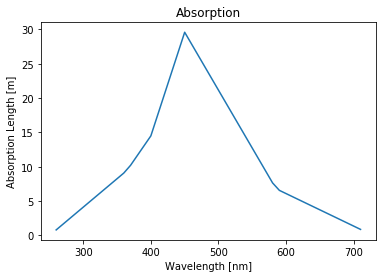

In [12]:
plt.figure()
plt.plot(wls, absLenTable)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Absorption Length [m]')
plt.title('Absorption')
plt.show()

In [13]:
# from WaterOpticalModule/MakePoneMediumPropertiesConservativeExtendedRange.py
# https://github.com/pone-software/pone_offline/blob/608423314880fe96e9bebf191923a9dd111aefa6/WaterOpticalModel/MakePoneMediumPropertiesConservativeExtendedRange.py

# petzold scattering angle distribution
deg = np.pi/180.

petzold_powerLawIndexBeforeFirstBin = -1.346
petzold_data_ang = [1e-9,
                    0.100*deg,   0.126*deg,   0.158*deg,   0.200*deg,   0.251*deg,
                    0.316*deg,   0.398*deg,   0.501*deg,   0.631*deg,   0.794*deg,
                    1.000*deg,   1.259*deg,   1.585*deg,   1.995*deg,   2.512*deg,
                    3.162*deg,   3.981*deg,   5.012*deg,   6.310*deg,   7.943*deg,
                    10.000*deg,  15.000*deg,  20.000*deg,  25.000*deg,  30.000*deg,
                    35.000*deg,  40.000*deg,  45.000*deg,  50.000*deg,  55.000*deg,
                    60.000*deg,  65.000*deg,  70.000*deg,  75.000*deg,  80.000*deg,
                    85.000*deg,  90.000*deg,  95.000*deg, 100.000*deg, 105.000*deg,
                    110.000*deg, 115.000*deg, 120.000*deg, 125.000*deg, 130.000*deg,
                    135.000*deg, 140.000*deg, 145.000*deg, 150.000*deg, 155.000*deg,
                    160.000*deg, 165.000*deg, 170.000*deg, 175.000*deg, 180.000*deg]
petzold_data_val=[0.,  # <- this 0 will be replaced right after the definition
                  1.767e+03, 1.296e+03, 9.502e+02, 6.991e+02, 5.140e+02,
                  3.764e+02, 2.763e+02, 2.188e+02, 1.444e+02, 1.022e+02,
                  7.161e+01, 4.958e+01, 3.395e+01, 2.281e+01, 1.516e+01,
                  1.002e+01, 6.580e+00, 4.295e+00, 2.807e+00, 1.819e+00,
                  1.153e+00, 4.893e-01, 2.444e-01, 1.472e-01, 8.609e-02,
                  5.931e-02, 4.210e-02, 3.067e-02, 2.275e-02, 1.699e-02,
                  1.313e-02, 1.046e-02, 8.488e-03, 6.976e-03, 5.842e-03,
                  4.953e-03, 4.292e-03, 3.782e-03, 3.404e-03, 3.116e-03,
                  2.912e-03, 2.797e-03, 2.686e-03, 2.571e-03, 2.476e-03,
                  2.377e-03, 2.329e-03, 2.313e-03, 2.365e-03, 2.506e-03,
                  2.662e-03, 2.835e-03, 3.031e-03, 3.092e-03, 3.154e-03]
# power law for values below bin 1
petzold_data_val[0] = 2.*np.pi*np.sin(petzold_data_ang[1])*petzold_data_val[1] * \
                       ((petzold_data_ang[0]/petzold_data_ang[1])**petzold_powerLawIndexBeforeFirstBin)

for i in range(len(petzold_data_val)):
    petzold_data_val[i] = 2.*np.pi*petzold_data_val[i]*np.sin(petzold_data_ang[i])

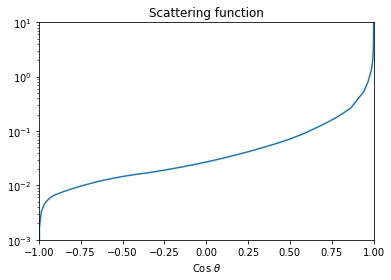

In [14]:
plt.figure()
plt.plot(np.cos(petzold_data_ang), petzold_data_val)
plt.yscale('log')
plt.xlim(-1, 1)
plt.ylim(1e-3, 1e1)
plt.xlabel('Cos $\\theta$')
plt.title('Scattering function')
plt.show()

## Check the data

In [23]:
f = dataio.I3File('/home/users/fhenningsen/pone_offline/Flasher/examples/test-flashes-new.i3')

In [24]:
frame = f.pop_daq()

In [25]:
frame.keys()

['BadDomsListSLC',
 'I3FlasherInfo_pulses',
 'SPEScalingFactors',
 'I3FlasherInfo_OMKeys',
 'BadDomsList',
 'MCTimeIncEventID',
 'I3ModuleGeoMap',
 'I3FlasherInfo',
 'I3EventHeader',
 'I3Photons',
 'StartTime',
 'SPEAbove',
 'I3OMGeoMap',
 'I3Geometry',
 'EndTime',
 'I3DetectorStatus',
 'Subdetectors',
 'I3Calibration']

In [26]:
print(frame['I3EventHeader'])

[ I3EventHeader:
        StartTime: 2012-01-10 05:20:50.961,584,445,8 UTC
         EndTime : 1905-06-04 18:35:44.000,000,000,0 UTC
           RunID : 1
        SubrunID : 0
         EventID : 1
      SubEventID : 0
  SubEventStream : 
]


In [27]:
print(frame['I3FlasherInfo'][0])

[FlasherInfo:
  Flashing OM : OMKey(5,10,1)
   Flash time : 0
     LED mask : 000000111111
   Brightness : 127
        Width : 127
         Rate : 0
]


In [29]:
ph = frame['I3Photons']

In [35]:
for i in ph.iteritems():
    print(i[0], len(i[1]), i[1][0].time)

ModuleKey(1,9) 25 351.093994140625
ModuleKey(1,10) 11695 322.0139465332031
ModuleKey(1,11) 28 569.7758178710938
ModuleKey(1,12) 2 602.2183227539062
ModuleKey(2,9) 2 568.364990234375
ModuleKey(2,10) 95 517.5265502929688
ModuleKey(2,11) 1 550.7970581054688
ModuleKey(3,9) 6 604.9398803710938
ModuleKey(3,10) 38 414.61297607421875
ModuleKey(3,11) 3 501.08294677734375
ModuleKey(4,8) 1 598.6707763671875
ModuleKey(4,9) 20 471.0231628417969
ModuleKey(4,10) 11993 272.22119140625
ModuleKey(4,11) 20 476.2008056640625
ModuleKey(5,9) 83 364.32794189453125
ModuleKey(5,10) 2564569 21.82828140258789
ModuleKey(5,11) 79 344.24761962890625
ModuleKey(6,8) 1 631.646484375
ModuleKey(6,9) 26 412.05029296875
ModuleKey(6,10) 11963 349.83551025390625
ModuleKey(6,11) 22 457.89776611328125
ModuleKey(7,8) 1 718.6185302734375
ModuleKey(7,9) 3 743.9575805664062
ModuleKey(7,10) 30 491.7519836425781
ModuleKey(7,11) 7 522.3260498046875
ModuleKey(8,10) 4 685.3068237304688
ModuleKey(9,9) 1 672.7897338867188
ModuleKey(9,10